In [1]:
library(purrr)
library(tidyverse)
library(edgeR)

Warning message in system("timedatectl", intern = TRUE):
“running command 'timedatectl' had status 1”
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.2     ✔ readr     2.1.4
✔ forcats   1.0.0     ✔ stringr   1.5.0
✔ ggplot2   3.4.2     ✔ tibble    3.2.1
✔ lubridate 1.9.2     ✔ tidyr     1.3.0
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Loading required package: limma



In [2]:
# Read the csv file
piRNAData <- read.csv("/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/analysis/sRNA_deseq/seqCount/alinged_count_matrix_12.5dpp.txt", header = TRUE, row.names = 1,sep='\t')# nrows = 10000)
piRNAData 




ERROR: Error in fread(file_path, skip = line_numbers - 1, nrows = num_lines, : length(skip) == 1L is not TRUE


In [ ]:
sampleName = c('129S1_SvImJ-P12.5','129S1_SvImJ-P12.5','129S1_SvImJ-P12.5','A_J-P12.5','A_J-P12.5','A_J-P12.5','AKR_J-P12.5','AKR_J-P12.5','AKR_J-P12.5','BALB_cJ-P12.5','BALB_cJ-P12.5','BALB_cJ-P12.5','C3H_HeJ-P12.5','C3H_HeJ-P12.5','C3H_HeJ-P12.5','C57BL_6NJ-P12.5','C57BL_6NJ-P12.5','C57BL_6NJ-P12.5','CAST_EiJ-P12.5','CAST_EiJ-P12.5','CAST_EiJ-P12.5','CBA_J-P12.5','CBA_J-P12.5','CBA_J-P12.5','DBA_2J-P12.5','DBA_2J-P12.5','DBA_2J-P12.5','FVB_NJ-P12.5','FVB_NJ-P12.5','FVB_NJ-P12.5','LP_J-P12.5','LP_J-P12.5','LP_J-P12.5','NOD_ShiLtJ-P12.5','NOD_ShiLtJ-P12.5','NOD_ShiLtJ-P12.5','NZO_HlLtJ-P12.5','NZO_HlLtJ-P12.5','NZO_HlLtJ-P12.5','PWK_PhJ-P12.5','PWK_PhJ-P12.5','PWK_PhJ-P12.5','SPRET_EiJ-P12.5','SPRET_EiJ-P12.5','SPRET_EiJ-P12.5','WSB_EiJ-P12.5','WSB_EiJ-P12.5','WSB_EiJ-P12.5')


lablesName = c('129S1_SvImJ-P12.5.1','129S1_SvImJ-P12.5.2','129S1_SvImJ-P12.5.3','A_J-P12.5.1','A_J-P12.5.2','A_J-P12.5.3','AKR_J-P12.5.1','AKR_J-P12.5.2','AKR_J-P12.5.3','BALB_cJ-P12.5.1','BALB_cJ-P12.5.2','BALB_cJ-P12.5.3','C3H_HeJ-P12.5.1','C3H_HeJ-P12.5.2','C3H_HeJ-P12.5.3','C57BL_6NJ-P12.5.1','C57BL_6NJ-P12.5.2','C57BL_6NJ-P12.5.3','CAST_EiJ-P12.5.1','CAST_EiJ-P12.5.2','CAST_EiJ-P12.5.3','CBA_J-P12.5.1','CBA_J-P12.5.2','CBA_J-P12.5.3','DBA_2J-P12.5.1','DBA_2J-P12.5.2','DBA_2J-P12.5.3','FVB_NJ-P12.5.1','FVB_NJ-P12.5.2','FVB_NJ-P12.5.3','LP_J-P12.5.1','LP_J-P12.5.2','LP_J-P12.5.3','NOD_ShiLtJ-P12.5.1','NOD_ShiLtJ-P12.5.2','NOD_ShiLtJ-P12.5.3','NZO_HlLtJ-P12.5.1','NZO_HlLtJ-P12.5.2','NZO_HlLtJ-P12.5.3','PWK_PhJ-P12.5.1','PWK_PhJ-P12.5.2','PWK_PhJ-P12.5.3','SPRET_EiJ-P12.5.1','SPRET_EiJ-P12.5.2','SPRET_EiJ-P12.5.3','WSB_EiJ-P12.5.1','WSB_EiJ-P12.5.2','WSB_EiJ-P12.5.3')


#samplenames = tools::file_path_sans_ext(tools::file_path_sans_ext(sub(".*/", "", f_files,perl = T)))
sampleNames_order = c('C57BL_6NJ-P12.5','C57BL_6NJ-P12.5','C57BL_6NJ-P12.5',
'BALB_cJ-P12.5','BALB_cJ-P12.5','BALB_cJ-P12.5',
'A_J-P12.5','A_J-P12.5','A_J-P12.5',
'FVB_NJ-P12.5','FVB_NJ-P12.5','FVB_NJ-P12.5',
'C3H_HeJ-P12.5','C3H_HeJ-P12.5','C3H_HeJ-P12.5',
'129S1_SvImJ-P12.5','129S1_SvImJ-P12.5','129S1_SvImJ-P12.5',
'DBA_2J-P12.5','DBA_2J-P12.5','DBA_2J-P12.5',
'AKR_J-P12.5','AKR_J-P12.5','AKR_J-P12.5',
'CBA_J-P12.5','CBA_J-P12.5','CBA_J-P12.5',
'NOD_ShiLtJ-P12.5','NOD_ShiLtJ-P12.5','NOD_ShiLtJ-P12.5',
'WSB_EiJ-P12.5','WSB_EiJ-P12.5','WSB_EiJ-P12.5',
'CAST_EiJ-P12.5','CAST_EiJ-P12.5','CAST_EiJ-P12.5',
'PWK_PhJ-P12.5','PWK_PhJ-P12.5','PWK_PhJ-P12.5',
'SPRET_EiJ-P12.5','SPRET_EiJ-P12.5','SPRET_EiJ-P12.5')

lablesName_order = c('C57BL_6NJ-P12.5.1','C57BL_6NJ-P12.5.2','C57BL_6NJ-P12.5.3',
'BALB_cJ-P12.5.1','BALB_cJ-P12.5.2','BALB_cJ-P12.5.3',
'A_J-P12.5.1','A_J-P12.5.2','A_J-P12.5.3',
'FVB_NJ-P12.5.1','FVB_NJ-P12.5.2','FVB_NJ-P12.5.3',
'C3H_HeJ-P12.5.1','C3H_HeJ-P12.5.2','C3H_HeJ-P12.5.3',
'129S1_SvImJ-P12.5.1','129S1_SvImJ-P12.5.2','129S1_SvImJ-P12.5.3',
'DBA_2J-P12.5.1','DBA_2J-P12.5.2','DBA_2J-P12.5.3',
'AKR_J-P12.5.1','AKR_J-P12.5.2','AKR_J-P12.5.3',
'CBA_J-P12.5.1','CBA_J-P12.5.2','CBA_J-P12.5.3',
'NOD_ShiLtJ-P12.5.1','NOD_ShiLtJ-P12.5.2','NOD_ShiLtJ-P12.5.3',
'WSB_EiJ-P12.5.1','WSB_EiJ-P12.5.2','WSB_EiJ-P12.5.3',
'CAST_EiJ-P12.5.1','CAST_EiJ-P12.5.2','CAST_EiJ-P12.5.3',
'PWK_PhJ-P12.5.1','PWK_PhJ-P12.5.2','PWK_PhJ-P12.5.3',
'SPRET_EiJ-P12.5.1','SPRET_EiJ-P12.5.2','SPRET_EiJ-P12.5.3')

In [ ]:
#change columns names 

colnames(piRNAData) <- lablesName 
piRNAData 

,129S1_SvImJ-P12.5.1,129S1_SvImJ-P12.5.2,129S1_SvImJ-P12.5.3,A_J-P12.5.1,A_J-P12.5.2,A_J-P12.5.3,AKR_J-P12.5.1,AKR_J-P12.5.2,AKR_J-P12.5.3,BALB_cJ-P12.5.1,⋯,NZO_HlLtJ-P12.5.3,PWK_PhJ-P12.5.1,PWK_PhJ-P12.5.2,PWK_PhJ-P12.5.3,SPRET_EiJ-P12.5.1,SPRET_EiJ-P12.5.2,SPRET_EiJ-P12.5.3,WSB_EiJ-P12.5.1,WSB_EiJ-P12.5.2,WSB_EiJ-P12.5.3
,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
AAGAAAGATTGCAAGAACTGCTAATTC,17337,29455,26903,20900,63749,29317,40996,47577,45834,51257,⋯,54596,48610,31786,32594,0,0,0,271142,430582,198712
TGACAAGGTTGTGATAACTCAAGCACT,11603,14475,8470,3189,4627,3956,9813,7798,8047,6149,⋯,15719,3906,1990,2274,1262,1638,1593,6304,8462,10078
TCTTTGTGTAGCCCTGAAGACCATACC,10019,15460,11272,3606,6088,4271,12805,11278,10176,9398,⋯,33833,22676,14425,16336,0,0,0,10604,16076,10224
ATCCAACTCACAATCTTCTGGGCTCCT,9170,16793,11133,13074,22323,16287,18870,20010,18862,19274,⋯,42194,15555,4542,8425,6515,9136,6576,6535,10849,12379
TGCAAGCTCAGAACCCAACAAACACGT,8553,11663,7983,3590,5946,3451,8385,7412,9226,9393,⋯,6666,3759,2567,1935,745,755,1006,10102,17123,12858
TAACAGAATCTGTAGGAACACCCTGCT,7657,10558,5549,6995,10670,7019,10021,8614,8703,19433,⋯,17562,0,0,0,0,0,0,8994,12958,9885
TAGTAGAACTCCGCTCTGAAGAGAACT,7354,10966,6274,9796,15251,10793,18189,15686,13330,25306,⋯,20371,20927,13564,14572,24506,27034,23992,12924,17742,12719
TACTTTCAAAGACTTTGAGCTGGCATC,7227,10191,7012,8583,13674,10123,17276,13919,11328,21988,⋯,24784,26593,27485,16487,0,0,0,8987,13561,10933
GCCGTGATCGTATAGTGGTTAGTACTC,6783,10573,6903,9746,16667,10430,19193,15866,19620,27476,⋯,17726,21177,14724,15705,15742,12783,14160,16066,18882,31726


In [ ]:
setwd("/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/analysis/sRNA_deseq/seqCount")

In [ ]:
# Now we build a DESeq2 Count dataset and normalize it.
library(DESeq2)
library(gplots)
library(RColorBrewer)
library(dplyr)
library(tidyr)
library(ggplot2)
library(ggrepel)
library(BiocParallel)
# Register 10 cores for parallel processing
register(MulticoreParam(workers = 1))

conds = data.frame(sampleName) ##what Desq2 manual calls coldata
colnames(conds)="sample"
cds <- DESeqDataSetFromMatrix(countData = piRNAData , colData = conds, design = ~ sample)
#cds <- estimateSizeFactors(cds)
#cds <- estimateDispersions(cds)
#cds <- nbinomWaldTest(cds)
cds <- DESeq(cds, parallel = TRUE)

Loading required package: S4Vectors



Loading required package: stats4

Loading required package: BiocGenerics


Attaching package: ‘BiocGenerics’


The following object is masked from ‘package:limma’:

    plotMA


The following objects are masked from ‘package:lubridate’:

    intersect, setdiff, union


The following objects are masked from ‘package:dplyr’:

    combine, intersect, setdiff, union


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, intersect, is.unsorted, lapply, Map, mapply,
    match, mget, order, paste, pmax, pmax.int, pmin, pmin.int,
    Position, rank, rbind, Reduce, rownames, sapply, setdiff, sort,
    table, tapply, union, unique, unsplit, which.max, which.min



Attaching package: ‘S4Vectors’


The following objects are masked from ‘package:lubridate

ERROR: Error in (function (cond) : error in evaluating the argument 'args' in selecting a method for function 'do.call': BiocParallel errors
  1 remote errors, element index: 1
  0 unevaluated and other errors
  first remote error:
Error: cannot allocate vector of size 9.7 Gb



In [ ]:
norm_counts <-counts(cds,normalized=TRUE)
norm_counts

,129S1_SvImJ-P12.5.1,129S1_SvImJ-P12.5.2,129S1_SvImJ-P12.5.3,A_J-P12.5.1,A_J-P12.5.2,A_J-P12.5.3,AKR_J-P12.5.1,AKR_J-P12.5.2,AKR_J-P12.5.3,BALB_cJ-P12.5.1,⋯,NZO_HlLtJ-P12.5.3,PWK_PhJ-P12.5.1,PWK_PhJ-P12.5.2,PWK_PhJ-P12.5.3,SPRET_EiJ-P12.5.1,SPRET_EiJ-P12.5.2,SPRET_EiJ-P12.5.3,WSB_EiJ-P12.5.1,WSB_EiJ-P12.5.2,WSB_EiJ-P12.5.3
AAGAAAGATTGCAAGAACTGCTAATTC,25944.404,30199.045,43756.793,33257.162,61755.539,45011.570,38298.379,48330.472,48364.906,29597.69178,⋯,32803.410,31960.45113,28281.38158,34809.65230,0.0000,0.0000,0.0000,248536.44852,266013.68602,185766.06899
TGACAAGGTTGTGATAACTCAAGCACT,17363.611,14840.644,13776.160,5074.502,4482.312,6073.806,9167.284,7921.496,8491.347,3550.66053,⋯,9444.589,2568.14487,1770.58923,2428.58039,1117.3390,1606.9585,1521.3678,5778.42522,5227.82608,9421.42620
TCTTTGTGTAGCCCTGAAGACCATACC,14993.193,15850.526,18333.516,5738.054,5897.625,6557.438,11962.405,11456.608,10737.908,5426.75356,⋯,20328.188,14909.17897,12834.54758,17446.47726,0.0000,0.0000,0.0000,9719.92720,9931.75752,9557.91442
ATCCAACTCACAATCTTCTGGGCTCCT,13722.685,17217.198,18107.437,20804.025,21624.949,25006.087,17628.315,20326.896,19903.540,11129.52204,⋯,25351.804,10227.21286,4041.21422,8997.70880,5768.1961,8962.8651,6280.2981,5990.16637,6702.51539,11572.51785
TGCAAGCTCAGAACCCAACAAACACGT,12799.359,11957.612,12984.072,5712.594,5760.066,5298.459,7833.250,7529.383,9735.450,5423.86638,⋯,4005.193,2471.49426,2283.97114,2066.53609,659.6019,740.6921,960.7634,9259.77976,10578.59443,12020.31138
TAACAGAATCTGTAGGAACACCCTGCT,11458.517,10824.699,9025.255,11130.806,10336.344,10776.553,9361.598,8750.419,9183.571,11221.33454,⋯,10551.936,0.00000,0.00000,0.00000,0.0000,0.0000,0.0000,8244.15553,8005.45620,9241.00000
TAGTAGAACTCCGCTCTGAAGAGAACT,11005.085,11243.005,10204.443,15587.902,14774.094,16570.927,16992.126,15934.417,14066.069,14612.62244,⋯,12239.693,13759.23392,12068.47857,15562.56530,21696.9169,26521.6829,22913.1558,11846.50501,10961.01281,11890.36712
TACTTTCAAAGACTTTGAGCTGGCATC,10815.032,10448.429,11404.774,13657.714,13246.408,15542.249,16139.204,14139.434,11953.521,12696.68624,⋯,14891.196,17484.55620,24454.59550,17607.74184,0.0000,0.0000,0.0000,8237.73913,8377.98978,10220.72362
GCCGTGATCGTATAGTGGTTAGTACTC,10150.597,10840.078,11227.489,15508.340,16145.815,16013.599,17930.061,16117.268,20703.396,15865.66087,⋯,10650.473,13923.60571,13100.58083,16772.58358,13937.5200,12540.7514,13523.2697,14726.55133,11665.30514,29659.07597
TCAGAGGACATGTTTTAATTGCGGAAA,9674.717,9926.571,10594.794,11073.521,13269.657,10736.634,10225.731,10499.690,10863.479,6872.65598,⋯,16881.175,10446.81358,10577.26874,10278.21359,968.5966,984.9734,1231.9928,11113.20231,9709.96721,12613.00678


In [ ]:

##NEXT IS THE TOP 15% VARIANT miRNA plot on the means. Then the subset more useful miRNA plot
library(pheatmap)
library(gplots)

foo_sub_1 <- as.data.frame.matrix(norm_counts) #convert from matrix to data frame
## use for eg foo$`hPGC_M_Wk9_n1` <- foo$`hPGC-M-Wk9_2` if only want one biol replicate

colnames(foo_sub_1)

head(foo_sub_1[ , grepl( "^129S1_SvImJ-12.5dpp" , names( foo_sub_1 ) ) ])
foo_sub1_mean = data.frame(matrix(NA, nrow = nrow(foo_sub_1), ncol = 0))
row.names(foo_sub1_mean) <- row.names(foo_sub_1)
for (sample in sampleName) {
foo_sub1_mean[sample] <- apply(foo_sub_1[ , grepl(paste0( "^",sample) , names( foo_sub_1 ) ) ], 1, mean)
}
head(foo_sub1_mean) 

foo_sub1_mean$sd_perGroup <- apply(foo_sub1_mean,1,sd)
hist(log1p(foo_sub1_mean$sd_perGroup),breaks = 200)


nrow(foo_sub1_mean)
3959
foo_sub1_mean_top15sd <- foo_sub1_mean[foo_sub1_mean$sd_perGroup>10959,1:16]
head(foo_sub1_mean_top15sd)
foo_sub1_mean_top15sd$ID<-rownames(foo_sub1_mean_top15sd)
head(foo_sub1_mean_top15sd)



save_pheatmap_pdf <- function(x, filename, width=15, height=25) {
    stopifnot(!missing(x))
    stopifnot(!missing(filename))
    pdf(filename, width=width, height=height,paper="special")
    grid::grid.newpage()
    grid::grid.draw(x$gtable)
    dev.off()
}

# Make a color scheme for heatmaps
hmcol = colorRampPalette(brewer.pal(9, "GnBu"))(100)
savePheatmap <- pheatmap(log1p(foo_sub1_mean_top15sd[,1:16]),width=2,height=3, border_color = NA,show_rownames = T, cluster_cols = F, labels_row = foo_sub1_mean_top15sd$ID,fontsize_row = 5, color = hmcol)


save_pheatmap_pdf(savePheatmap,"P12.5_InitialPheatMap.pdf")

In [ ]:
library(gplots)
library(RColorBrewer)
##for z-score
myCol <- rev(colorRampPalette(brewer.pal(11, "RdBu"))(100))



savePheatmapZScore <- pheatmap(foo_sub1_mean_top15sd[,1:16],,width=2,height=3, border_color = NA,show_rownames = T, cluster_cols = F,scale = "row",labels_row = foo_sub1_mean_top15sd$ID,fontsize_row = 5, color = myCol)

save_pheatmap_pdf(savePheatmapZScore,"P12.5_InitialPheatMap_zScore.pdf")

In [ ]:

raw_counts <- counts(cds, normalized=FALSE)

# Calculate mean expression across replicates for each sample
mean_expr_per_sample <- apply(raw_counts, 1, function(x) {
  sapply(unique(dds$colData), function(y) {
    mean(x[dds$colData == y])
  })
})

# Identify genes with non-zero expression in one sample and zero in all others
selected_genes <- apply(mean_expr_per_sample, 1, function(x) {
  nonzero_samples = names(x)[x != 0]
  if (length(nonzero_samples) == 1 && all(x[x != nonzero_samples] == 0)) {
    return(nonzero_samples)
  } else {
    return(NULL)
  }
})

# Filter out NULL values and create a data frame of selected genes and samples
selected_genes <- Filter(Negate(is.null), selected_genes)
gene_sample_pairs <- data.frame(
  Gene = names(selected_genes),
  Sample = unlist(selected_genes)
)

# Save the results to a CSV file
write.csv(gene_sample_pairs, "zero_expression_raw_count_sample_pairs.csv", row.names = FALSE)


In [ ]:
library(MGFR)
markers.list <- getMarkerGenes.rnaseq(norm_counts, class.vec = sampleName ,samples2compare="all",score.cuto=0.5)

write.csv(t(sapply(markers.list, unlist)), file = "P12.5_marker_alinged.tab")
write.csv(rapply(markers.list, length, how="list"), file = "P12.5_marker_alinged_count.tab")
# Convert the list to FASTA format with unique headers
convert_to_fasta <- function(data_list, output_file) {
  con <- file(output_file, "w")
  header_count <- list()
  
  for (name in names(data_list)) {
    sequences <- unlist(strsplit(data_list[[name]], "'"))
    
    for (seq_info in sequences) {
      split_data <- unlist(strsplit(seq_info, " : "))
      if(length(split_data) == 2) {
        sequence <- split_data[1]
        value <- split_data[2]
        
        # Construct the base header and then check for repetitions
        base_header <- paste(name, "_", value, sep="")
        if (!base_header %in% names(header_count)) {
          header_count[[base_header]] <- 1
          header <- paste(">", base_header, sep="")
        } else {
          header_count[[base_header]] <- header_count[[base_header]] + 1
          header <- paste(">", base_header, "_", header_count[[base_header]], sep="")
        }
        
        cat(header, "\n", sequence, "\n", file=con)
      }
    }
  }
  close(con)
}

# Call the function to write to a FASTA file
convert_to_fasta(markers.list, "P12.5_marker_alinged.fasta")

Detecting marker genes...
Done! 


In [ ]:
pdf("P12.5_deseq2_BarGraphBeforeAfter.pdf",paper="a4")
par(mfrow=c(2,1))

par(mar=c(10,4,0,2)) # increase y-axis margin.
prenorm=apply(piRNAData ,2,sum)
barplot(prenorm,col=as.factor(sampleName),las=2,names=sampleName, cex.names = 0.6, cex.axis = 0.8)
postnorm=apply(norm_counts ,2,sum)
barplot(postnorm,col=as.factor(sampleName),las=2,names=sampleName ,cex.names = 0.6, cex.axis = 0.8)
dev.off()




png 
  2

In [ ]:
library(gplots)
library(RColorBrewer)
library(dplyr)
library(tidyr)
library(ggplot2)
library(ggrepel)

# Make a color scheme for heatmaps
hmcol = colorRampPalette(brewer.pal(9, "GnBu"))(100)
# First we tell DESeq which samples correspond to which tissues.

pdf("P12.5_InitialHeatMap.pdf",paper="special",width=15, height=15,title="E16,5",fillOddEven=T)
heatmap.2(cor(norm_counts),trace="none",col=hmcol,main="Sample Correlation",cexRow=1,cexCol=1,
    margins=c(15,15),na.rm=T,key=T,offsetRow=1,offsetCol=1,keysize=0.4,density.info='histogram')
dev.off()

png 
  2

In [ ]:
##And the Spearman Dendogram

foo_cor_1 = cor(norm_counts, method = "spearman") #builds matrix of Spearman corrn and euclidean distances

foo_cor_dist_1 = dist(foo_cor_1, method = "euclidean")
pdf(file="P12.5_dendrogram.pdf", height=8, width=15)
plot(hclust(foo_cor_dist_1))
dev.off()

png 
  2


Attaching package: ‘gridExtra’


The following object is masked from ‘package:Biobase’:

    combine


The following object is masked from ‘package:BiocGenerics’:

    combine


The following object is masked from ‘package:dplyr’:

    combine




,PC1,PC2,PC3,Strains,Variance_PC1,Variance_PC2,Variance_PC3,Shape,Unique_Strains
,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
129S1_SvImJ-P12.5.1,-20297.689,-33400.8349,-24931.24,129S1_SvImJ-P12.5,50.54716,22.84512,11.64905,P12.5,129S1_SvImJ
129S1_SvImJ-P12.5.2,19095.527,-24387.8842,-21148.91,129S1_SvImJ-P12.5,50.54716,22.84512,11.64905,P12.5,129S1_SvImJ
129S1_SvImJ-P12.5.3,-13160.319,-9989.2008,-19791.79,129S1_SvImJ-P12.5,50.54716,22.84512,11.64905,P12.5,129S1_SvImJ
A_J-P12.5.1,-4975.401,-20147.5991,-21898.69,A_J-P12.5,50.54716,22.84512,11.64905,P12.5,A_J
A_J-P12.5.2,-5147.213,2985.4393,-17571.87,A_J-P12.5,50.54716,22.84512,11.64905,P12.5,A_J
A_J-P12.5.3,-12009.711,2968.8120,-16886.47,A_J-P12.5,50.54716,22.84512,11.64905,P12.5,A_J
AKR_J-P12.5.1,1210.025,-20877.7232,-24282.27,AKR_J-P12.5,50.54716,22.84512,11.64905,P12.5,AKR_J
AKR_J-P12.5.2,-3395.254,-3909.6793,-21089.00,AKR_J-P12.5,50.54716,22.84512,11.64905,P12.5,AKR_J
AKR_J-P12.5.3,-16988.131,-3956.3571,-23290.88,AKR_J-P12.5,50.54716,22.84512,11.64905,P12.5,AKR_J


TableGrob (3 x 1) "arrange": 3 grobs
  z     cells    name           grob
1 1 (1-1,1-1) arrange gtable[layout]
2 2 (2-2,1-1) arrange gtable[layout]
3 3 (3-3,1-1) arrange gtable[layout]


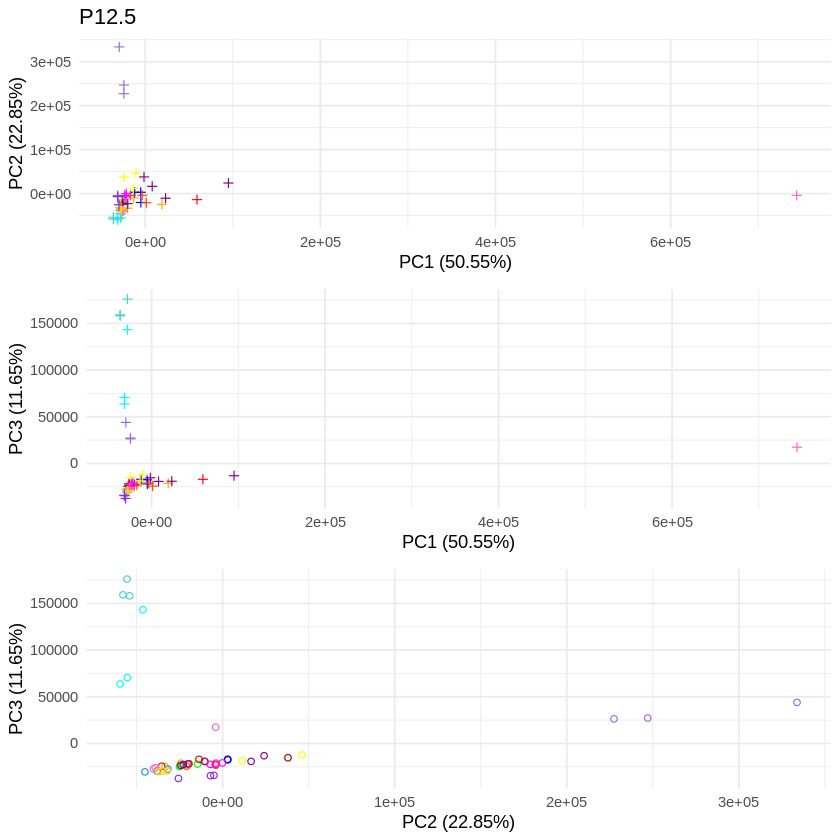

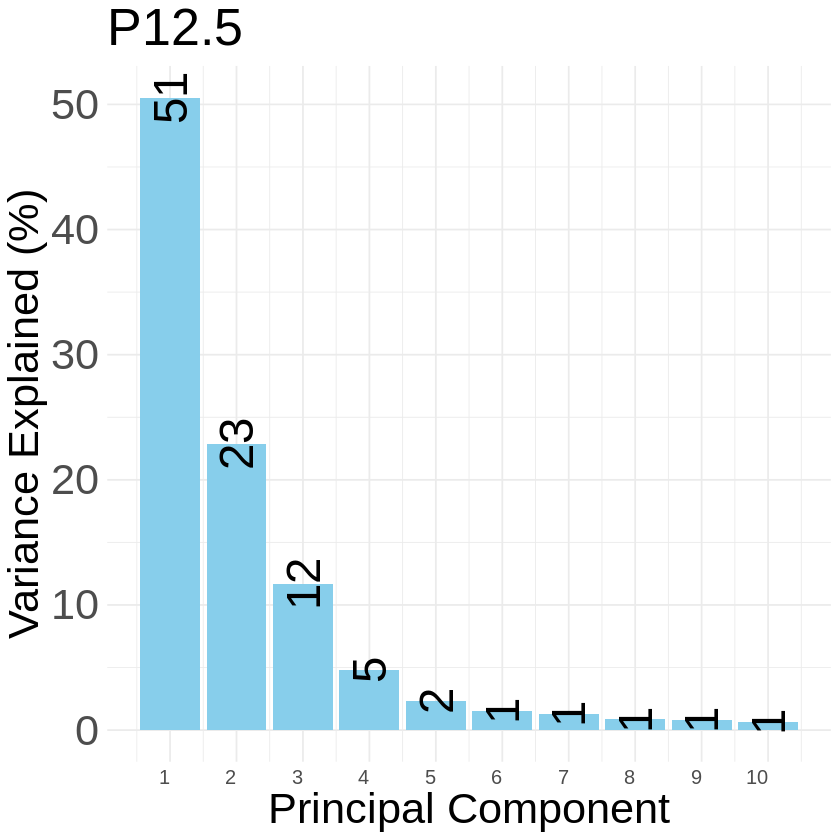

In [ ]:
library(edgeR)
library(ggplot2)
library(gridExtra)

# Sample data for illustration purposes
set.seed(123)

samplenames_order =  c('C57BL_6NJ','C57BL_6NJ','C57BL_6NJ',
'BALB_cJ','BALB_cJ','BALB_cJ',
'A_J','A_J','A_J',
'FVB_NJ','FVB_NJ','FVB_NJ',
'C3H_HeJ','C3H_HeJ','C3H_HeJ','LP_J',
'129S1_SvImJ','129S1_SvImJ','129S1_SvImJ',
'DBA_2J','DBA_2J','DBA_2J',
'AKR_J','AKR_J','AKR_J',
'CBA_J','CBA_J','CBA_J',
'NOD_ShiLtJ','NOD_ShiLtJ','NOD_ShiLtJ','NZO_HlLtJ',
'WSB_EiJ','WSB_EiJ','WSB_EiJ',
'CAST_EiJ','CAST_EiJ','CAST_EiJ',
'PWK_PhJ','PWK_PhJ','PWK_PhJ',
'SPRET_EiJ','SPRET_EiJ','SPRET_EiJ')


# Perform PCA on normalized count data
pca <- prcomp(t(norm_counts))



# Calculate the variance explained by each PC
variance_explained <- pca$sdev^2 / sum(pca$sdev^2) * 100

# Generate a color palette based on the number of unique sample names

custom_colors <- c(
  '#FF0000',  # Bright Red
  '#00FF00',  # Bright Green
  '#0000FF',  # Bright Blue
  '#FF00FF',  # Bright Magenta
  '#FFFF00',  # Bright Yellow
  '#00FFFF',  # Bright Cyan
  '#FFA500',  # Orange
  '#800080',  # Purple
  '#FF4500',  # Deep Orange
  '#8B008B',  # Dark Magenta
  '#FF69B4',  # Hot Pink
  '#48D1CC',  # Teal
  '#9370DB',  # Lavender
  '#1E90FF',  # Royal Blue
  '#FFD700',  # Gold
  '#8A2BE2',  # Blue Violet
  '#FF6347',  # Tomato
  '#008000'   # Dark Green
)
# Create a data frame for PCA results and variance explained
pca_data <- data.frame(PC1 = pca$x[, 1], PC2 = pca$x[, 2], PC3 = pca$x[, 3], Strains = sampleName,
                       Variance_PC1 = variance_explained[1], Variance_PC2 = variance_explained[2], Variance_PC3 = variance_explained[3])

# Create individual PCA plots with unique colors
  # Create a new column 'Shape' based on the sample names
pca_data$Shape <- ifelse(grepl("12.5", pca_data$Strains ), "P12.5",
            ifelse(grepl("16.5", pca_data$Strains ), "P12.5",
                   ifelse(grepl("20.5", pca_data$Strains ), "P12.5", "D")))
# Extract unique strain names from the "Strains" column
pca_data$Unique_Strains <- sapply(strsplit(pca_data$Strains, "-"), function(x) x[1])

pca_data


# Calculate the variance explained by each PC
variance_explained <- pca$sdev^2 / sum(pca$sdev^2) * 100




# Create individual PCA plots with unique colors
# Create individual PCA plots with unique colors and shapes for the legend
pca_plot_pc1_pc2 <- ggplot(pca_data, aes(x = PC1, y = PC2, color = Unique_Strains, shape = Shape)) +
  geom_point() +
  scale_color_manual(values = custom_colors,breaks = unique(samplenames_order)) + 
  labs(title = "P12.5", x = paste("PC1 (", round(variance_explained[1], 2), "%)", sep = ""), 
       y = paste("PC2 (", round(variance_explained[2], 2), "%)", sep = "")) +
  scale_shape_manual(values = c("P12.5" = 3, "P12.5" = 1, "P20.5" = 17, "D" = 19)) +
  theme_minimal() + labs(shape = "Timepoint")  +
  theme(legend.position = "none") 

pca_plot_pc1_pc3 <- ggplot(pca_data, aes(x = PC1, y = PC3, color = Unique_Strains, shape = Shape)) +
  geom_point() +
  scale_color_manual(values = custom_colors,breaks = unique(samplenames_order)) + 
  labs( x = paste("PC1 (", round(variance_explained[1], 2), "%)", sep = ""), 
       y = paste("PC3 (", round(variance_explained[3], 2), "%)", sep = "")) +
  scale_shape_manual(values = c("P12.5" = 3, "P12.5" = 1, "P20.5" = 17, "D" = 19)) +
  theme_minimal() + labs(shape = "Timepoint")  +
  theme(legend.position = "none") 


pca_plot_pc2_pc3 <- ggplot(pca_data, aes(x = PC2, y = PC3, color = Unique_Strains, shape = Shape)) +
  geom_point() +
  scale_color_manual(values = custom_colors,breaks = unique(samplenames_order)) + 
  labs( x = paste("PC2 (", round(variance_explained[2], 2), "%)", sep = ""), 
       y = paste("PC3 (", round(variance_explained[3], 2), "%)", sep = "")) +
  scale_shape_manual(values = c("E16.5" = 3, "P12.5" = 1, "P20.5" = 17, "D" = 19)) +
  theme_minimal() + labs(shape = "Timepoint")  +
  theme(legend.position = "none") 






# Create a custom layout matrix for vertical arrangement
layout_mat <- rbind(c(1), c(2), c(3))
# Define custom widths for each plot
custom_widths <- c(15, 15, 15)  # Adjust these values as needed
custom_heights <- c(3, 3, 3) 

# Create the grid of PCA plots
grid <- grid.arrange(pca_plot_pc1_pc2, pca_plot_pc1_pc3, pca_plot_pc2_pc3,
                     nrow = 3, ncol = 1, layout_matrix = layout_mat, widths = c(0.5), heights = custom_heights)

# Show the grid
print(grid)
# Save the grid as a PDF file
ggsave("P12.5_deseq2_PCA.pdf", grid, width = 3, height = 5, units = "in")

# Calculate the variance explained by each PC
variance_explained <- pca$sdev^2 / sum(pca$sdev^2) * 100

# Create a data frame for variance explained by first 10 PCs
variance_df <- data.frame(PC = 1:10, VarianceExplained = variance_explained[1:10])

# Create a bar plot with labels on bars and sky blue color
variance_bar_plot <- ggplot(variance_df, aes(x = PC, y = VarianceExplained, label = round(VarianceExplained, 2))) +
  geom_bar(stat = "identity", fill = "skyblue") +
  geom_text(aes(label = paste(round(VarianceExplained))),vjust = 0.5 ,size = 10, angle = 90, parse = TRUE) +  # Add text labels above the bars
  labs(title = "P12.5", title.size = 16,  # Increase title size
       x = "Principal Component", y = "Variance Explained (%)", x.size = 14, y.size = 14) +  # Increase axis label size
  theme_minimal() +
  scale_x_continuous(breaks = 1:10) +
  theme(axis.text.x = element_text(angle = 0, hjust = 1, size = 12),  # Increase x-axis label size
        axis.text.y = element_text(size = 26),  # Increase y-axis label size
        title = element_text(size = 26),  # Increase title size
        axis.title = element_text(size = 26))  # Increase axis title size
# Show the bar plot
print(variance_bar_plot)
# Save the bar plot as a PDF file
ggsave("P12.5_variance_explained_bar_plot.pdf", variance_bar_plot, width = 3, height = 4, units = "in")

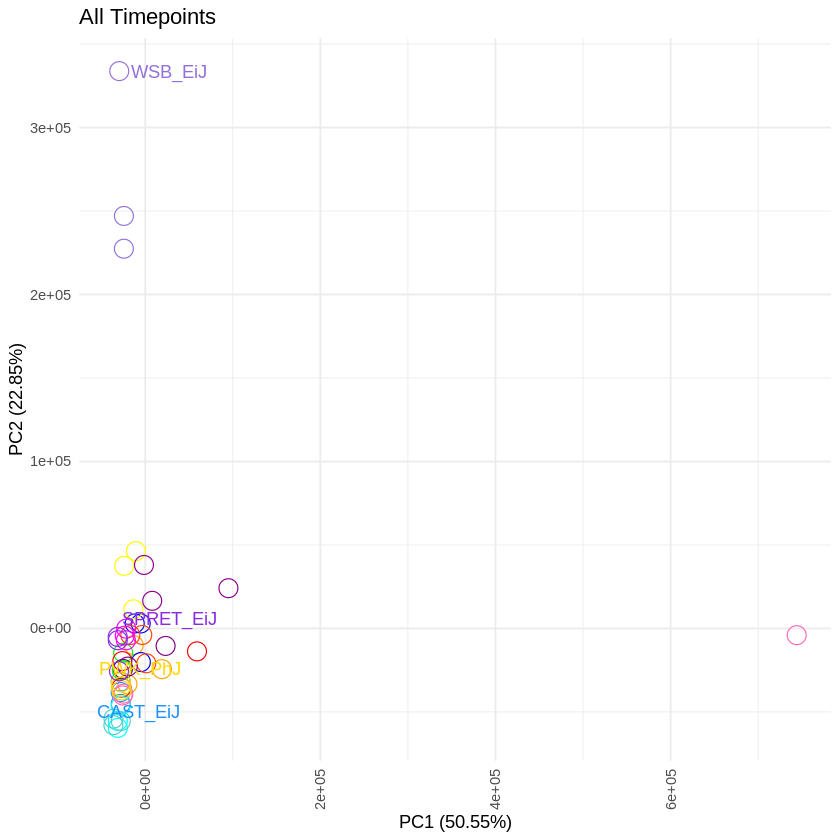

In [ ]:

library(ggforce)
# Create the PCA plot
pca_plot_pc1_pc2 <- ggplot(pca_data, aes(x = PC1, y = PC2, color = Unique_Strains, shape = Shape)) +
  geom_point(size=5) +
  scale_color_manual(values = custom_colors, breaks = unique(samplenames_order)) + 
  labs(title = "All Timepoints", x = paste("PC1 (", round(variance_explained[1], 2), "%)", sep = ""), 
       y = paste("PC2 (", round(variance_explained[2], 2), "%)", sep = "")) +
  theme_minimal() + 
  scale_shape_manual(values = c("E16.5" = 3, "P12.5" = 1, "P20.5" = 17, "D" = 19)) +  
  labs(shape = "Timepoint") + labs(color = "Strains")  +
  theme(legend.position = "none", axis.text.x = element_text(angle = 90, vjust = 0.5))  # Rotating x-axis labels




# Filter the data for specific unique strain values
selected_strains <- c("SPRET_EiJ", "WSB_EiJ", "CAST_EiJ", "PWK_PhJ")
filtered_data <- pca_data %>%
  filter(Shape == "P12.5", Unique_Strains %in% selected_strains)



# Adjust the jitter parameters for better label spacing
jitter_amount <- 4
pca_plot_pc1_pc2 <- pca_plot_pc1_pc2 +
  geom_text_repel(
    data = filtered_data %>% distinct(Unique_Strains, .keep_all = TRUE),
    aes(label = Unique_Strains, color = Unique_Strains),
    nudge_x = 0, nudge_y = 0,  # No need for nudge with jitter
    segment.color = "black",
    segment.size = 0.5,
    #arrow = arrow(type = "closed", angle = 90, length = unit(1, "inches")),
    box.padding = unit(0.4, "lines"),  # Adjust padding around labels
    point.padding = unit(0.2, "lines"),  # Adjust padding around points
    force = 10
  )

# Print the modified PCA plot
print(pca_plot_pc1_pc2)
ggsave("P12.5_timepoint_PC1_PC2.pdf", plot = pca_plot_pc1_pc2, width = 3, height = 5)

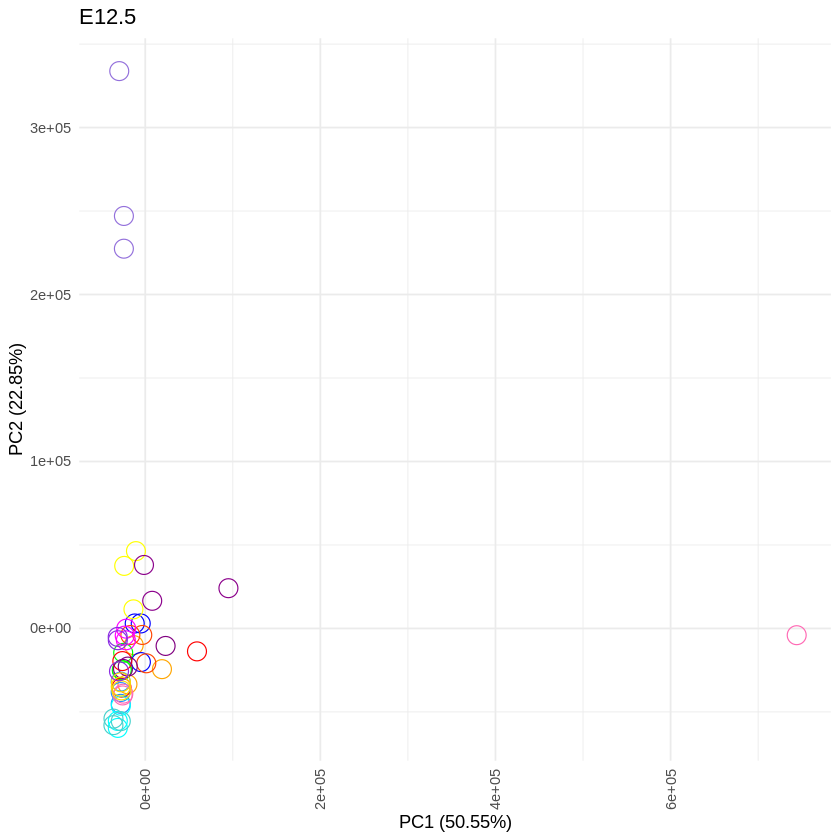

In [ ]:
pca_plot_pc1_pc2 <- ggplot(pca_data, aes(x = PC1, y = PC2, color = Unique_Strains, shape = Shape)) +
  geom_point(size=5) +
  scale_color_manual(values = custom_colors, breaks = unique(samplenames_order)) + 
  labs(title = "E12.5", x = paste("PC1 (", round(variance_explained[1], 2), "%)", sep = ""), 
       y = paste("PC2 (", round(variance_explained[2], 2), "%)", sep = "")) +
  scale_shape_manual(values = c("E16.5" = 3, "P12.5" = 1, "P20.5" = 17, "D" = 19)) + 
  theme_minimal() +
  labs(shape = "Timepoint") +
  labs(color = "Strains") +
  theme(legend.position = "none", axis.text.x = element_text(angle = 90, vjust = 0.5))  # Rotating x-axis labels


# Print the modified PCA plot
print(pca_plot_pc1_pc2)
ggsave("P12.5_deseq2_PCA.pdf", pca_plot_pc1_pc2, width = 3, height = 5, units = "in")

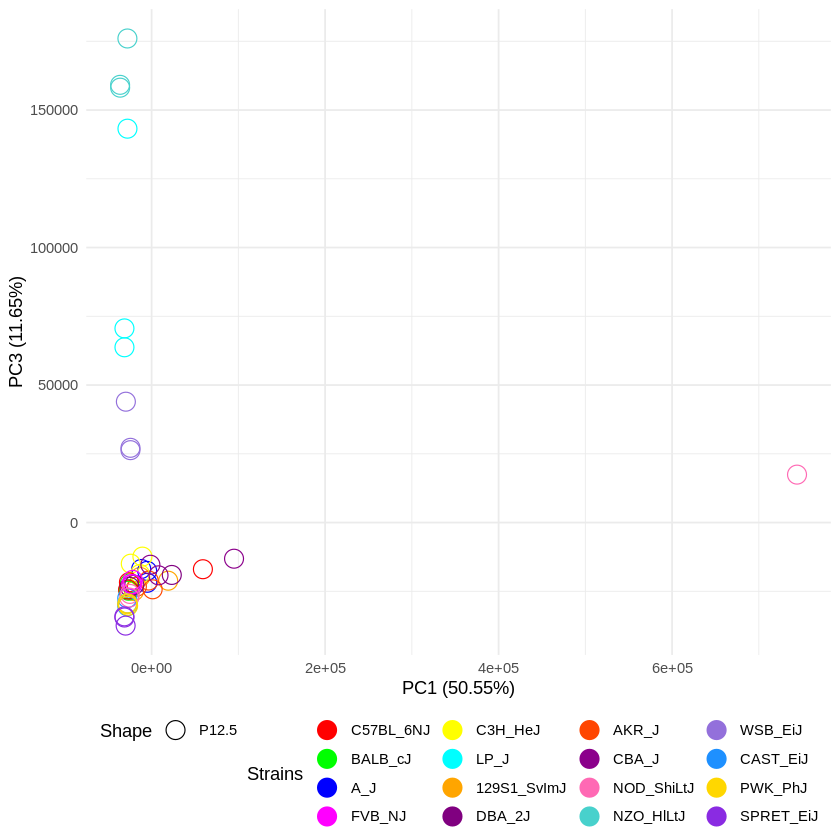

In [ ]:
# Existing code (excluding the print command)
pca_plot_pc1_pc3 <- ggplot(pca_data, aes(x = PC1, y = PC3, color = Unique_Strains, shape = Shape)) +
  geom_point(size=5) +
  scale_color_manual(values = custom_colors, breaks = unique(samplenames_order)) + 
  labs(x = paste("PC1 (", round(variance_explained[1], 2), "%)", sep = ""), 
       y = paste("PC3 (", round(variance_explained[3], 2), "%)", sep = "")) +
  scale_shape_manual(values = c("E16.5" = 3, "P12.5" = 1, "P12.5" = 17, "D" = 19)) +
  labs(color = "Strains") +
  theme_minimal() +
  theme(legend.direction = "horizontal", legend.position = "bottom")

# Adjust the width of the plot
pca_plot_pc1_pc3 <- pca_plot_pc1_pc3 + theme(legend.box = "horizontal") +
  theme(legend.margin = margin(t = 0, unit = "cm"), 
        legend.spacing = unit(0.2, "cm"))

# Print the plot
print(pca_plot_pc1_pc3)


In [ ]:
install.packages("pheatmap")

[1] "129S1_SvImJ-P12.5.1" "129S1_SvImJ-P12.5.2" "129S1_SvImJ-P12.5.3"
 [4] "A_J-P12.5.1"         "A_J-P12.5.2"         "A_J-P12.5.3"        
 [7] "AKR_J-P12.5.1"       "AKR_J-P12.5.2"       "AKR_J-P12.5.3"      
[10] "BALB_cJ-P12.5.1"     "BALB_cJ-P12.5.2"     "BALB_cJ-P12.5.3"    
[13] "C3H_HeJ-P12.5.1"     "C3H_HeJ-P12.5.2"     "C3H_HeJ-P12.5.3"    
[16] "C57BL_6NJ-P12.5.1"   "C57BL_6NJ-P12.5.2"   "C57BL_6NJ-P12.5.3"  
[19] "CAST_EiJ-P12.5.1"    "CAST_EiJ-P12.5.2"    "CAST_EiJ-P12.5.3"   
[22] "CBA_J-P12.5.1"       "CBA_J-P12.5.2"       "CBA_J-P12.5.3"      
[25] "DBA_2J-P12.5.1"      "DBA_2J-P12.5.2"      "DBA_2J-P12.5.3"     
[28] "FVB_NJ-P12.5.1"      "FVB_NJ-P12.5.2"      "FVB_NJ-P12.5.3"     
[31] "LP_J-P12.5.1"        "LP_J-P12.5.2"        "LP_J-P12.5.3"       
[34] "NOD_ShiLtJ-P12.5.1"  "NOD_ShiLtJ-P12.5.2"  "NOD_ShiLtJ-P12.5.3" 
[37] "NZO_HlLtJ-P12.5.1"   "NZO_HlLtJ-P12.5.2"   "NZO_HlLtJ-P12.5.3"  
[40] "PWK_PhJ-P12.5.1"     "PWK_PhJ-P12.5.2"     "PWK_PhJ-P12.5.3"    
[43] "SPRET_EiJ-P12.5.1"   "SPRET_EiJ-P12.5.2"   "SPRET_EiJ-P12.5.3"  
[46] "WSB_EiJ-P12.5.1"     "WSB_EiJ-P12.5.2"     "WSB_EiJ-P12.5.3"

AAGAAAGATTGCAAGAACTGCTAATTC
TGACAAGGTTGTGATAACTCAAGCACT
TCTTTGTGTAGCCCTGAAGACCATACC
ATCCAACTCACAATCTTCTGGGCTCCT
TGCAAGCTCAGAACCCAACAAACACGT
TAACAGAATCTGTAGGAACACCCTGCT


,129S1_SvImJ-P12.5,A_J-P12.5,AKR_J-P12.5,BALB_cJ-P12.5,C3H_HeJ-P12.5,C57BL_6NJ-P12.5,CAST_EiJ-P12.5,CBA_J-P12.5,DBA_2J-P12.5,FVB_NJ-P12.5,LP_J-P12.5,NOD_ShiLtJ-P12.5,NZO_HlLtJ-P12.5,PWK_PhJ-P12.5,SPRET_EiJ-P12.5,WSB_EiJ-P12.5
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
AAGAAAGATTGCAAGAACTGCTAATTC,33300.08,46674.757,44997.919,34479.164,97567.353,33646.216,18439.341,90302.623,43188.153,58450.910,26959.447,33495.768,35127.329,31683.828,0.0000,233438.735
TGACAAGGTTGTGATAACTCAAGCACT,15326.81,5210.206,8526.709,3505.293,9817.012,3006.493,2973.005,18274.182,28803.214,8621.381,7826.366,17279.757,9338.465,2255.771,1415.2218,6809.226
TCTTTGTGTAGCCCTGAAGACCATACC,16392.41,6064.372,11385.640,6025.160,7862.349,11982.770,12712.565,9043.302,7231.629,7603.470,8176.206,5341.363,20739.862,15063.401,0.0000,9736.533
ATCCAACTCACAATCTTCTGGGCTCCT,16349.11,22478.354,19286.251,11968.446,13687.293,7323.872,1326.075,10596.249,17830.730,9759.286,8197.811,6841.834,25661.439,7755.379,7003.7864,8088.400
TGCAAGCTCAGAACCCAACAAACACGT,12580.35,5590.373,8366.028,5509.545,10438.461,3447.690,9650.790,22978.290,18870.099,6278.778,8399.804,19599.357,3410.760,2274.000,787.0191,10619.562
TAACAGAATCTGTAGGAACACCCTGCT,10436.16,10747.901,9098.529,10449.099,9727.007,10353.087,0.000,8068.532,12242.383,10775.808,12245.503,10548.872,10384.122,0.000,0.0000,8496.871


[1] 27121822

[1] 3959

,129S1_SvImJ-P12.5,A_J-P12.5,AKR_J-P12.5,BALB_cJ-P12.5,C3H_HeJ-P12.5,C57BL_6NJ-P12.5,CAST_EiJ-P12.5,CBA_J-P12.5,DBA_2J-P12.5,FVB_NJ-P12.5,LP_J-P12.5,NOD_ShiLtJ-P12.5,NZO_HlLtJ-P12.5,PWK_PhJ-P12.5,SPRET_EiJ-P12.5,WSB_EiJ-P12.5
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
AAGAAAGATTGCAAGAACTGCTAATTC,33300.081,46674.757,44997.919,34479.1638,97567.353,33646.216,18439.34143,90302.623,43188.153,58450.910,26959.4468,33495.768,35127.329,31683.8283,0.0000,233438.7345
TCACCCTGATGAACTGAATACCGCCCC,13887.117,21961.644,15202.996,6212.6594,13636.680,6621.776,6841.50427,5553.126,1377.470,9193.301,6210.7420,4615.980,11841.958,829.8341,7406.4497,130069.3344
GCATTGGTGGTTCAGTGGTAGAATTCT,11361.293,17394.960,16621.412,11774.7514,24501.130,11150.926,7668.89437,23710.990,8574.231,13642.235,6139.7851,6075.292,13898.457,3630.7460,73421.2544,175439.6073
TACCAGTTGGATAATGCACTTCCTATT,18018.448,13439.485,10816.043,418.4370,5199.557,20736.166,90.25141,33757.609,10308.553,2679.481,2120.7724,130802.621,2589.499,207.5880,0.0000,840.5296
TAACGTACGTATGTTTGAAATGTGACT,9564.968,7805.015,6738.706,239.8963,3953.148,14636.263,68.10237,20126.831,8073.217,2002.162,1143.5191,79771.332,1861.570,126.1561,266.9960,513.6616
TGAGATACCAGACTGTCAGACGTTGGC,6599.913,5145.070,5227.848,188.1158,2091.611,8513.439,54.07557,14104.069,4902.590,1515.797,746.7819,52140.808,1118.102,69.7385,234.9858,439.9808


,129S1_SvImJ-P12.5,A_J-P12.5,AKR_J-P12.5,BALB_cJ-P12.5,C3H_HeJ-P12.5,C57BL_6NJ-P12.5,CAST_EiJ-P12.5,CBA_J-P12.5,DBA_2J-P12.5,FVB_NJ-P12.5,LP_J-P12.5,NOD_ShiLtJ-P12.5,NZO_HlLtJ-P12.5,PWK_PhJ-P12.5,SPRET_EiJ-P12.5,WSB_EiJ-P12.5,ID
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
AAGAAAGATTGCAAGAACTGCTAATTC,33300.081,46674.757,44997.919,34479.1638,97567.353,33646.216,18439.34143,90302.623,43188.153,58450.910,26959.4468,33495.768,35127.329,31683.8283,0.0000,233438.7345,AAGAAAGATTGCAAGAACTGCTAATTC
TCACCCTGATGAACTGAATACCGCCCC,13887.117,21961.644,15202.996,6212.6594,13636.680,6621.776,6841.50427,5553.126,1377.470,9193.301,6210.7420,4615.980,11841.958,829.8341,7406.4497,130069.3344,TCACCCTGATGAACTGAATACCGCCCC
GCATTGGTGGTTCAGTGGTAGAATTCT,11361.293,17394.960,16621.412,11774.7514,24501.130,11150.926,7668.89437,23710.990,8574.231,13642.235,6139.7851,6075.292,13898.457,3630.7460,73421.2544,175439.6073,GCATTGGTGGTTCAGTGGTAGAATTCT
TACCAGTTGGATAATGCACTTCCTATT,18018.448,13439.485,10816.043,418.4370,5199.557,20736.166,90.25141,33757.609,10308.553,2679.481,2120.7724,130802.621,2589.499,207.5880,0.0000,840.5296,TACCAGTTGGATAATGCACTTCCTATT
TAACGTACGTATGTTTGAAATGTGACT,9564.968,7805.015,6738.706,239.8963,3953.148,14636.263,68.10237,20126.831,8073.217,2002.162,1143.5191,79771.332,1861.570,126.1561,266.9960,513.6616,TAACGTACGTATGTTTGAAATGTGACT
TGAGATACCAGACTGTCAGACGTTGGC,6599.913,5145.070,5227.848,188.1158,2091.611,8513.439,54.07557,14104.069,4902.590,1515.797,746.7819,52140.808,1118.102,69.7385,234.9858,439.9808,TGAGATACCAGACTGTCAGACGTTGGC


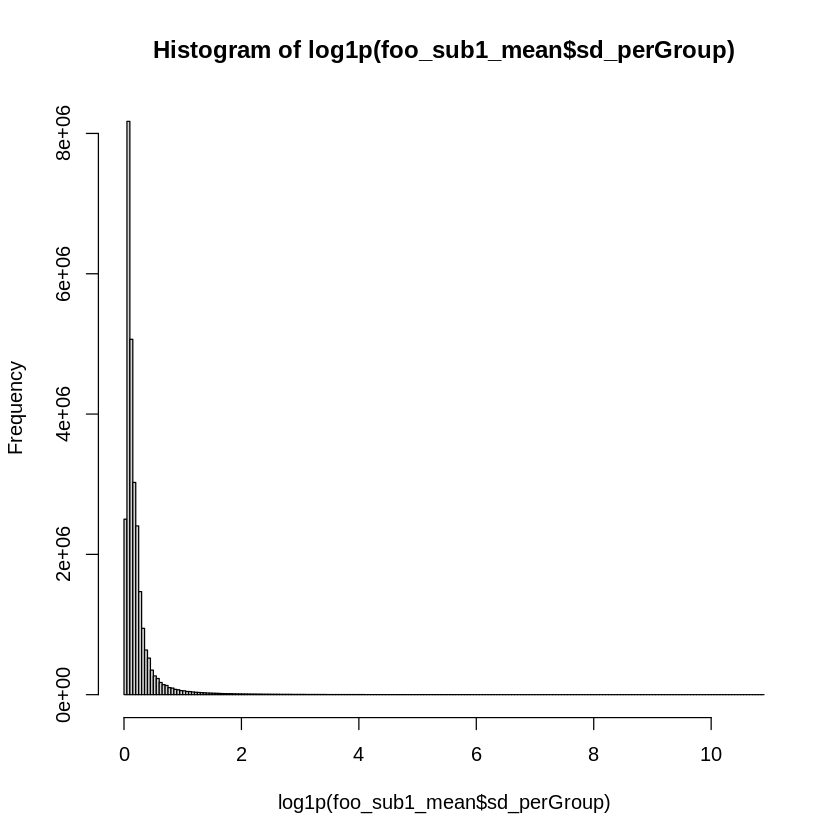

png 
  2

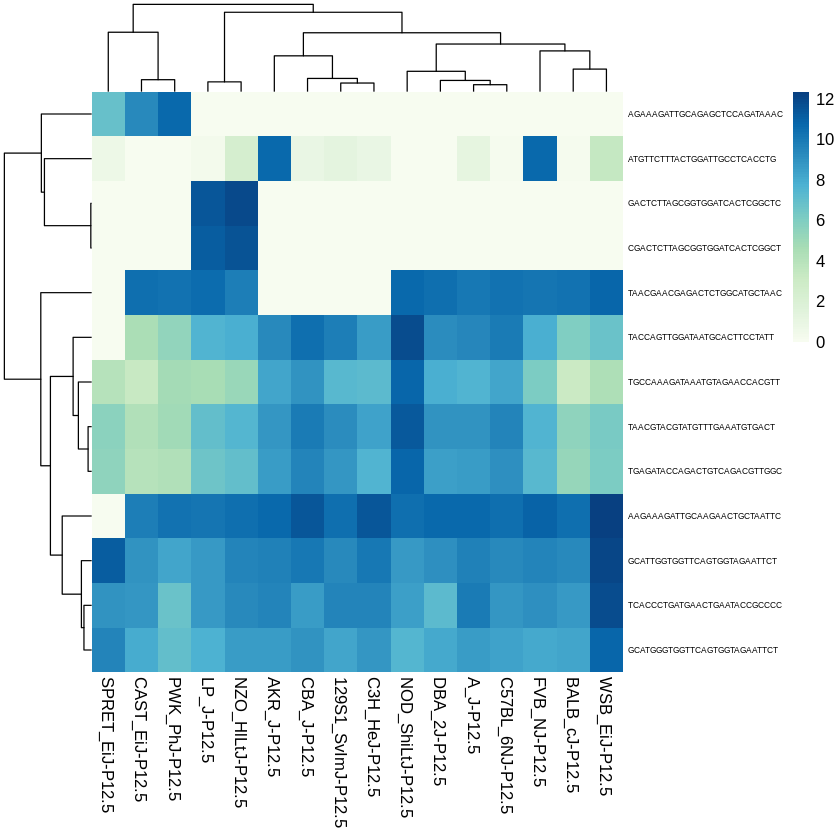

png 
  2

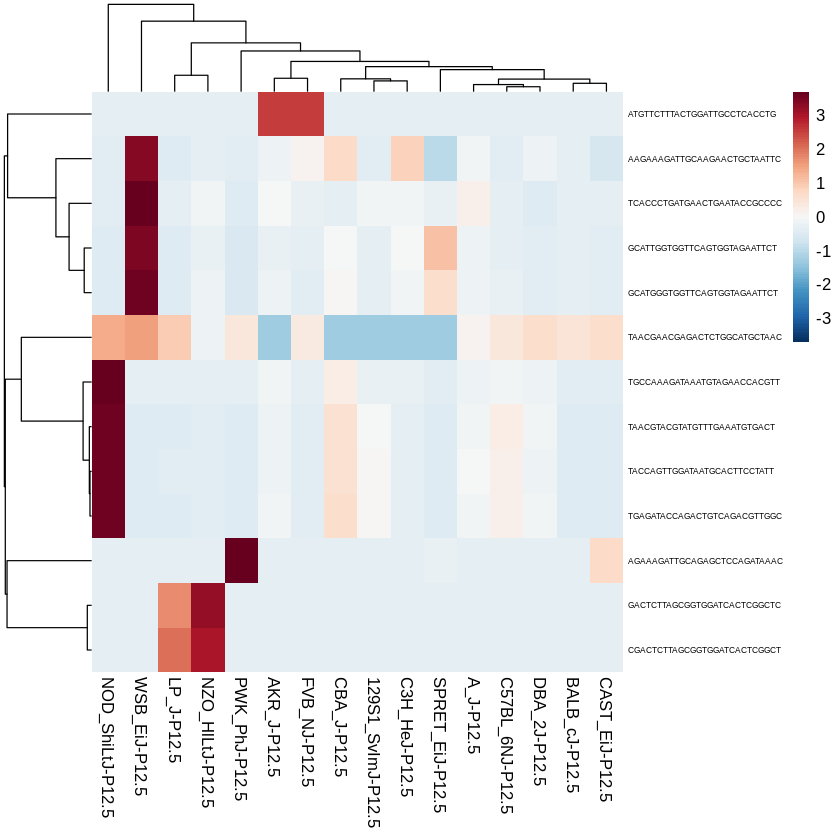